# 0. Lesson 4 Introduction

## Tushuncha
Lesson 3 da biz **Model Architecture** mavzusini o'rgandik: model qanday layerlardan tuziladi, CNN qanday ishlaydi, Conv2d, ReLU, Pooling va Linear layerlar nima vazifa bajaradi.

Lesson 4 da esa model **qanday o'rganishini** o'rganamiz. Ya'ni model faqat layerlardan iborat bo'lib qolmaydi, u rasm va label misollaridan xatolarini ko'rib, weightlarini yangilab boradi.

Phase 3 — Training & Optimization quyidagi qismlardan iborat:

1. Forward Pass
2. Loss Calculation
3. Backpropagation
4. Optimizer
5. Validation
6. Epoch / Batch
7. Training Loop

## Real-life analogy
Bu jarayon talabaning dars tayyorlashiga o'xshaydi:

- Talaba savolni ko'radi.
- Javob beradi.
- Teacher xatosini ko'rsatadi.
- Talaba xatosini tushunib, keyingi safar yaxshiroq javob beradi.

## Oddiy diagram
Input Image -> Model -> Prediction -> Loss -> Backpropagation -> Optimizer Update -> Better Model

## Kod
Quyidagi kod lesson flow ni oddiy matn sifatida chiqaradi.
        


In [1]:
lesson4_flow = "Input Image -> Model -> Prediction -> Loss -> Backpropagation -> Optimizer Update -> Better Model"
print(lesson4_flow)
        


Input Image -> Model -> Prediction -> Loss -> Backpropagation -> Optimizer Update -> Better Model


## Qisqa xulosa
Lesson 4 ning asosiy maqsadi: model prediction qiladi, loss orqali xatosini o'lchaydi, backpropagation orqali gradientlarni hisoblaydi va optimizer orqali weightlarni yangilaydi.
        


---

# 1. Setup: Import Libraries

## Tushuncha
Bu darsda PyTorch yordamida image classification modelini train qilamiz.

- **PyTorch** — neural network yaratish, forward pass, loss, gradient va optimizer bilan ishlash uchun kerak.
- **torchvision** — image datasetlar, image transformlar va computer vision uchun tayyor utilitalarni beradi.
- **matplotlib** — rasm, loss graph va accuracy graphlarni ko'rsatish uchun kerak.
- **numpy** — tensorlarni rasm ko'rinishida chizishda yordam beradi.

## Real-life analogy
Bu kutubxonalar oshxonadagi asbob-uskunalarga o'xshaydi:

- PyTorch = asosiy pishirish uskunalari.
- torchvision = tayyor masalliqlar va rasm datasetlari.
- matplotlib = natijani doskada chizib ko'rsatish.

## Kod
Kutubxonalarni import qilamiz, CPU/GPU device ni tekshiramiz va dars uchun kerakli papkalarni tayyorlaymiz.
        


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt
import numpy as np
import random
import json
from pathlib import Path

# Natijalar qayta ishga tushirilganda ham taxminan bir xil bo'lishi uchun seed qo'yamiz.
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# CPU-friendly dars: default holatda CPU ishlatamiz.
# Agar keyin GPU ishlatmoqchi bo'lsangiz, use_gpu_if_available = True qiling.
use_gpu_if_available = False
device = torch.device("cuda" if use_gpu_if_available and torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Notebook qayerdan ishga tushirilishidan qat'i nazar, Lesson4 va data yo'llarini topamiz.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "Lesson4":
    LESSON_DIR = PROJECT_ROOT
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    LESSON_DIR = PROJECT_ROOT / "Lesson4"

DATA_DIR = PROJECT_ROOT / "data"
LESSON_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Lesson folder:", LESSON_DIR)
print("Data folder:", DATA_DIR)
        


Using device: cpu
Lesson folder: C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 1\4 dars\Lesson4
Data folder: C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 1\4 dars\data


## Qisqa xulosa
Setup bosqichida kerakli kutubxonalar import qilindi, device CPU qilib tanlandi va dars fayllari uchun yo'llar tayyorlandi.
        


---

# 2. Dataset Preparation for Training

## Tushuncha
Model o'rganishi uchun unga **data** kerak. Image classification model odatda ikki narsadan o'rganadi:

- **image** — kiruvchi rasm.
- **label** — rasm qaysi classga tegishli ekanini bildiradi.

Dataset modelga ko'p misollar beradi. Model shu misollardan umumiy patternlarni o'rganadi.

Bu notebook siz oldindan yuklab qo'ygan CIFAR-10 datasetini `data/` papkasidan ishlatadi. Notebook avval `data/cifar-10-batches-py` extracted folderini ochishga harakat qiladi. Agar Windows permission sababli bu folder ochilmasa, `data/cifar-10-python.tar.gz` local archive faylidan CIFAR-10 ni to'g'ridan-to'g'ri o'qiydi. Internetdan download qilish shart emas.

FakeData faqat local CIFAR-10 umuman o'qilmasa fallback sifatida ishlatiladi.

## Real-life analogy
Dataset mashq daftariga o'xshaydi. Har bir rasm va label bitta mashq savoli va uning to'g'ri javobidir.

## Tensor shape tushunchasi
PyTorch image batch shakli odatda quyidagicha bo'ladi:

`[batch_size, channels, height, width]`

Masalan CIFAR-10 uchun:

`[32, 3, 32, 32]`

Bu degani:

- 32 ta rasm bitta batch ichida.
- 3 ta channel: Red, Green, Blue.
- Har bir rasm 32x32 piksel.

## Kod
Local `data/` papkasidan CIFAR-10 ni yuklaymiz, transform qilamiz, DataLoader yaratamiz va bitta batchni ko'ramiz.


Expected extracted CIFAR-10 folder: C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 1\4 dars\data\cifar-10-batches-py
Expected local CIFAR-10 archive: C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 1\4 dars\data\cifar-10-python.tar.gz
CIFAR-10 local data papkasidan yuklandi.
Dataset: CIFAR-10 (local extracted folder)
Full train dataset size: 50000
Full test dataset size: 10000
Training examples used: 2000
Test examples used: 500
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
One batch image shape: torch.Size([32, 3, 32, 32])
One batch label shape: torch.Size([32])
Shape meaning: [batch_size, channels, height, width]


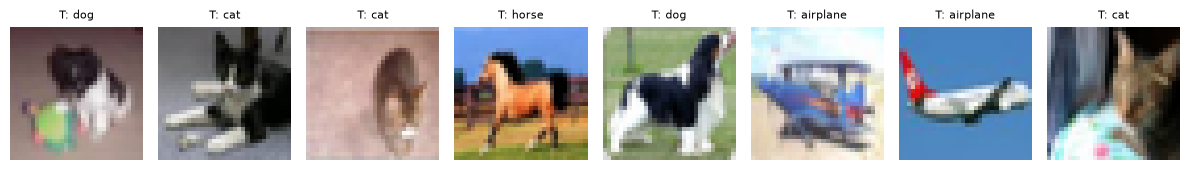

In [3]:
# CIFAR-10 class nomlari
cifar10_classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Image transform:
# 1) Resize: hamma rasm 32x32 bo'lishi uchun
# 2) ToTensor: PIL image ni PyTorch tensoriga aylantiradi
# 3) Normalize: qiymatlarni taxminan -1 va 1 oralig'iga olib keladi
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 32

# Sizning oldindan yuklab qo'yilgan CIFAR-10 fayllaringiz shu yerda bo'lishi kerak.
CIFAR_EXTRACTED_DIR = DATA_DIR / "cifar-10-batches-py"
CIFAR_ARCHIVE_PATH = DATA_DIR / "cifar-10-python.tar.gz"

print("Expected extracted CIFAR-10 folder:", CIFAR_EXTRACTED_DIR)
print("Expected local CIFAR-10 archive:", CIFAR_ARCHIVE_PATH)


class CIFAR10FromLocalArchive(torch.utils.data.Dataset):
    # data/cifar-10-python.tar.gz faylini extract qilmasdan o'qiydigan Dataset.
    def __init__(self, archive_path, train=True, transform=None):
        import pickle
        import tarfile
        from PIL import Image

        self.archive_path = Path(archive_path)
        self.train = train
        self.transform = transform
        self._image_class = Image

        if not self.archive_path.exists():
            raise FileNotFoundError(f"Archive topilmadi: {self.archive_path}")

        with tarfile.open(self.archive_path, "r:gz") as tar:
            meta_member = self._find_member(tar, "batches.meta")
            with tar.extractfile(meta_member) as f:
                meta = pickle.load(f, encoding="latin1")
            self.classes = meta.get("label_names", cifar10_classes)

            if train:
                batch_names = [f"data_batch_{i}" for i in range(1, 6)]
            else:
                batch_names = ["test_batch"]

            data_parts = []
            label_parts = []

            for batch_name in batch_names:
                member = self._find_member(tar, batch_name)
                with tar.extractfile(member) as f:
                    batch = pickle.load(f, encoding="latin1")

                data_parts.append(batch["data"])
                label_parts.extend(batch["labels"])

        self.data = np.concatenate(data_parts, axis=0)
        self.data = self.data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        self.targets = label_parts

    @staticmethod
    def _find_member(tar, suffix):
        for member in tar.getmembers():
            if member.name.endswith(suffix):
                return member
        raise FileNotFoundError(f"CIFAR-10 archive ichida {suffix} topilmadi.")

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        image = self._image_class.fromarray(self.data[index])
        label = int(self.targets[index])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


def load_local_cifar10():
    # 1-usul: torchvision bilan extracted CIFAR-10 folderni o'qish.
    try:
        train_ds = torchvision.datasets.CIFAR10(
            root=str(DATA_DIR),
            train=True,
            download=False,
            transform=transform
        )
        test_ds = torchvision.datasets.CIFAR10(
            root=str(DATA_DIR),
            train=False,
            download=False,
            transform=transform
        )
        return train_ds, test_ds, train_ds.classes, "CIFAR-10 (local extracted folder)"

    except Exception as extracted_error:
        print("Extracted CIFAR-10 folder ochilmadi.")
        print("Sabab:", extracted_error)

    # 2-usul: data/cifar-10-python.tar.gz archive faylini extract qilmasdan o'qish.
    if CIFAR_ARCHIVE_PATH.exists():
        print("Local archive orqali CIFAR-10 yuklanmoqda...")
        train_ds = CIFAR10FromLocalArchive(
            archive_path=CIFAR_ARCHIVE_PATH,
            train=True,
            transform=transform
        )
        test_ds = CIFAR10FromLocalArchive(
            archive_path=CIFAR_ARCHIVE_PATH,
            train=False,
            transform=transform
        )
        return train_ds, test_ds, train_ds.classes, "CIFAR-10 (local tar.gz archive)"

    raise FileNotFoundError(
        "Local CIFAR-10 topilmadi. data/cifar-10-batches-py yoki "
        "data/cifar-10-python.tar.gz kerak."
    )


try:
    train_dataset, test_dataset, classes, dataset_name = load_local_cifar10()
    print("CIFAR-10 local data papkasidan yuklandi.")
except Exception as local_data_error:
    print("Local CIFAR-10 o'qilmadi. FakeData fallback ishlatiladi.")
    print("Sabab:", local_data_error)

    dataset_name = "FakeData"
    classes = cifar10_classes
    train_dataset = torchvision.datasets.FakeData(
        size=2000,
        image_size=(3, 32, 32),
        num_classes=10,
        transform=transform
    )
    test_dataset = torchvision.datasets.FakeData(
        size=500,
        image_size=(3, 32, 32),
        num_classes=10,
        transform=transform
    )

# CPU-friendly training uchun kichik subset ishlatamiz.
# To'liq CIFAR-10 da 50,000 train rasm bor, CPU da bu sekin bo'lishi mumkin.
use_small_subset = True
train_subset_size = 2000
test_subset_size = 500

if use_small_subset:
    train_data_for_loader = Subset(train_dataset, range(min(train_subset_size, len(train_dataset))))
    test_data_for_loader = Subset(test_dataset, range(min(test_subset_size, len(test_dataset))))
else:
    train_data_for_loader = train_dataset
    test_data_for_loader = test_dataset

train_loader = DataLoader(
    train_data_for_loader,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_data_for_loader,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Dataset:", dataset_name)
print("Full train dataset size:", len(train_dataset))
print("Full test dataset size:", len(test_dataset))
print("Training examples used:", len(train_data_for_loader))
print("Test examples used:", len(test_data_for_loader))
print("Class names:", classes)

# Bitta batch olib shape ni tekshiramiz
images, labels = next(iter(train_loader))
print("One batch image shape:", images.shape)
print("One batch label shape:", labels.shape)
print("Shape meaning: [batch_size, channels, height, width]")


def denormalize(image_tensor):
    # Normalize qilingan rasmni yana 0..1 oralig'iga qaytaradi.
    return image_tensor / 2 + 0.5


def show_image_grid(images, labels=None, predictions=None, confidences=None, max_images=8):
    # Batch ichidagi bir nechta rasmni ko'rsatish uchun helper function.
    count = min(max_images, images.shape[0])
    plt.figure(figsize=(12, 3))

    for i in range(count):
        image = denormalize(images[i].cpu()).clamp(0, 1)
        np_image = image.numpy().transpose((1, 2, 0))

        plt.subplot(1, count, i + 1)
        plt.imshow(np_image)
        plt.axis("off")

        title_parts = []
        if labels is not None:
            true_idx = int(labels[i])
            title_parts.append(f"T: {classes[true_idx]}")
        if predictions is not None:
            pred_idx = int(predictions[i])
            title_parts.append(f"P: {classes[pred_idx]}")
        if confidences is not None:
            title_parts.append(f"{float(confidences[i]) * 100:.1f}%")

        if title_parts:
            plt.title("\n".join(title_parts), fontsize=8)

    plt.tight_layout()
    plt.show()


show_image_grid(images, labels, max_images=8)


## Qisqa xulosa
Dataset model uchun mashq misollaridir. DataLoader datasetni kichik batchlarga bo'lib beradi. Batch shape `[32, 3, 32, 32]` bo'lsa, bu 32 ta RGB rasm degani.
        


---

# 3. Batch nima?

## Tushuncha
**Batch** — datasetdan bir vaqtda modelga beriladigan kichik qism.

Butun datasetni birdan modelga berish og'ir bo'lishi mumkin. Shuning uchun training odatda mini-batchlar bilan qilinadi.

Mini-batch training:

- xotirani kamroq ishlatadi.
- trainingni qulayroq qiladi.
- gradientlarni tez-tez yangilashga yordam beradi.

## Real-life analogy
Kitobni birdaniga to'liq yodlash qiyin. Odatda uni sahifa-sahifa yoki bob-bob o'qiymiz.

Dataset = butun kitob.  
Batch = bitta sahifa yoki kichik bob.

## Kod
Bitta batch olib, image va label shape larini ko'ramiz. Keyin batch ichidan 8 ta rasmni chiqaramiz.
        


images.shape: torch.Size([32, 3, 32, 32])
labels.shape: torch.Size([32])
First labels as numbers: [5, 5, 2, 2, 9, 8, 4, 6]
First labels as names: ['dog', 'dog', 'bird', 'bird', 'truck', 'ship', 'deer', 'frog']


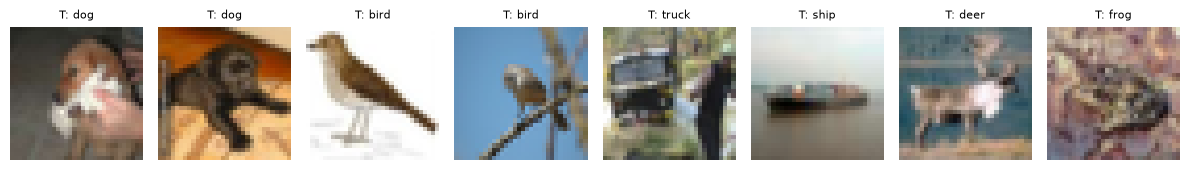

In [4]:
batch_images, batch_labels = next(iter(train_loader))

print("images.shape:", batch_images.shape)
print("labels.shape:", batch_labels.shape)
print("First labels as numbers:", batch_labels[:8].tolist())
print("First labels as names:", [classes[i] for i in batch_labels[:8].tolist()])

show_image_grid(batch_images, batch_labels, max_images=8)
        


## Qisqa xulosa
Outputdagi `images.shape` batch ichida nechta rasm borligini va har bir rasmning channel, height, width qiymatlarini ko'rsatadi. `labels.shape` esa batchdagi har bir rasm uchun bitta label borligini bildiradi.
        


---

# 4. Epoch nima?

## Tushuncha
**Epoch** — model butun training datasetni bir marta ko'rib chiqishi.

Masalan:

- Datasetda 1000 ta rasm bor.
- Batch size = 100.
- Demak 1 epoch = 10 batch.

Ko'p epoch modelga ko'proq o'rganish imkonini beradi. Lekin juda ko'p epoch modelni overfittingga olib kelishi mumkin.

## Real-life analogy
Epoch kitobni boshidan oxirigacha bir marta o'qib chiqishga o'xshaydi. Agar kitobni 3 marta o'qisangiz, bu 3 epochga o'xshaydi.

## Hisoblash
`Dataset size / Batch size = Batches per epoch`

## Kod
Training loader ichida nechta batch borligini hisoblaymiz.
        


In [5]:
num_batches = len(train_loader)
print("Training examples used:", len(train_data_for_loader))
print("Batch size:", batch_size)
print("Batches per epoch:", num_batches)

manual_estimate = int(np.ceil(len(train_data_for_loader) / batch_size))
print("Manual estimate ceil(dataset_size / batch_size):", manual_estimate)
        


Training examples used: 2000
Batch size: 32
Batches per epoch: 63
Manual estimate ceil(dataset_size / batch_size): 63


## Qisqa xulosa
1 epoch ichida model train datasetdagi hamma misollarni batch-batch qilib ko'radi. `len(train_loader)` bitta epochda nechta batch bo'lishini beradi.
        


---

# 5. Simple CNN Model Architecture

## Tushuncha
Lesson 3 da architecture o'rgandik. Endi shu architecture training jarayonida ishlatiladi.

CNN image ichidan featurelarni ajratadi:

- birinchi convolution oddiy patternlarni ko'radi.
- keyingi convolution murakkabroq patternlarni ko'radi.
- linear layerlar class prediction chiqaradi.

## Real-life analogy
CNN rasmni bosqichma-bosqich tahlil qiladigan kuzatuvchiga o'xshaydi:

1. Avval chiziq va ranglarni ko'radi.
2. Keyin shakllarni ko'radi.
3. Oxirida "bu qaysi class?" degan qarorga keladi.

## Architecture
Input: `3 x 32 x 32`

Conv2d -> ReLU -> MaxPool2d -> Conv2d -> ReLU -> MaxPool2d -> Flatten -> Linear -> ReLU -> Linear

## Kod
Simple CNN model yaratamiz, devicega o'tkazamiz va bitta batch orqali output shape ni ko'ramiz.
        


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Input: [batch, 3, 32, 32]
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Pooldan keyin: [batch, 16, 16, 16]
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Ikkinchi pooldan keyin: [batch, 32, 8, 8]
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


model = SimpleCNN(num_classes=len(classes)).to(device)
print(model)

sample_images, sample_labels = next(iter(train_loader))
sample_outputs = model(sample_images.to(device))

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)
print("Expected output: [batch_size, number_of_classes]")
print("Number of classes:", len(classes))
        


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
Input shape: torch.Size([32, 3, 32, 32])
Output shape: torch.Size([32, 10])
Expected output: [batch_size, number_of_classes]
Number of classes: 10


## Qisqa xulosa
Model input sifatida `[batch_size, 3, 32, 32]` rasm oladi va output sifatida `[batch_size, 10]` logits chiqaradi. CIFAR-10 da 10 ta class bor.
        


---

# 6. Forward Pass nima?

## Tushuncha
**Forward pass** — input image model ichidan oldinga qarab o'tadi va prediction chiqadi.

Bu bosqichda model hali o'rganmaydi. U faqat mavjud weightlar bilan javob chiqaradi.

Output qiymatlar odatda **logits** deyiladi. Logits hali probability emas. Softmax orqali ularni probabilityga aylantiramiz.

## Real-life analogy
Talaba savolni o'qiydi va javob beradi. Hali teacher feedback bermadi, ya'ni talaba hali xatosini bilmaydi.

## Kod
Bitta batchni modelga beramiz, logits, probability va predicted classni ko'ramiz.
        


In [7]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("outputs.shape:", outputs.shape)
print("First image raw output/logits:")
print(outputs[0].detach().cpu().numpy().round(3))

# Softmax logitsni probabilityga aylantiradi.
probs = torch.softmax(outputs, dim=1)
predicted_class = torch.argmax(probs[0]).item()

print("First image probabilities:")
print(probs[0].detach().cpu().numpy().round(3))
print("Predicted class index:", predicted_class)
print("Predicted class name:", classes[predicted_class])
print("Confidence:", f"{probs[0][predicted_class].item() * 100:.2f}%")
        


outputs.shape: torch.Size([32, 10])
First image raw output/logits:
[-0.075  0.103 -0.069 -0.064  0.07   0.1   -0.062 -0.113  0.005  0.012]
First image probabilities:
[0.093 0.112 0.094 0.094 0.108 0.111 0.095 0.09  0.101 0.102]
Predicted class index: 1
Predicted class name: automobile
Confidence: 11.15%


## Qisqa xulosa
Forward pass prediction chiqaradi. `outputs` raw logits, `softmax` probability, `argmax` esa eng katta probabilityga ega classni tanlaydi.
        


---

# 7. Loss Calculation nima?

## Tushuncha
**Loss** model predictioni qanchalik noto'g'ri ekanini o'lchaydi.

- Loss katta bo'lsa, model xatosi katta.
- Loss kichik bo'lsa, model predictioni yaxshiroq.

Classification uchun odatda `CrossEntropyLoss` ishlatiladi. U raw logits va true labels ni solishtiradi.

## Real-life analogy
Imtihonda 100 balldan 70 oldingiz. Xato = 30 ball.

Loss ham shunga o'xshaydi: modelning xatosini raqam bilan o'lchaydi.

## Kod
CrossEntropyLoss yaratamiz va bitta batch uchun loss hisoblaymiz.
        


Loss value: 2.304957389831543
True label: bird
Predicted label: automobile
Prediction correct? False


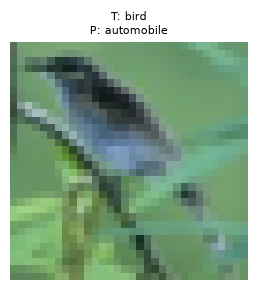

In [8]:
criterion = nn.CrossEntropyLoss()

loss = criterion(outputs, labels)
print("Loss value:", loss.item())

# Bitta rasm uchun predicted label va true labelni ko'ramiz.
first_image = images[0].detach().cpu()
true_label = labels[0].item()
pred_label = torch.argmax(outputs[0]).item()

print("True label:", classes[true_label])
print("Predicted label:", classes[pred_label])
print("Prediction correct?", true_label == pred_label)

show_image_grid(first_image.unsqueeze(0), torch.tensor([true_label]), torch.tensor([pred_label]), max_images=1)
        


## Qisqa xulosa
Loss modelning xatosini ko'rsatadi. `CrossEntropyLoss` classificationda ko'p ishlatiladi va past loss yaxshiroq natija degani.
        


---

# 8. Backpropagation nima?

## Tushuncha
**Backpropagation** — loss xatosini orqaga yuborib, har bir weight qaysi tomonga o'zgarishi kerakligini hisoblaydi.

Bu jarayonda **gradientlar** hisoblanadi. Gradient weightni qanday o'zgartirish kerakligi haqida signal beradi.

Muhim: `loss.backward()` weightlarni hali o'zgartirmaydi. U faqat gradientlarni hisoblaydi.

## Real-life analogy
Teacher talabaning xatosini ko'rsatadi:

- "Bu joyda noto'g'ri o'ylading."
- "Mana bu mavzuni qayta ko'r."

Backpropagation ham modelga qaysi weightlar xatoga ta'sir qilganini ko'rsatadi.

## Kod
Optimizer yaratamiz, gradientlarni tozalaymiz, forward pass qilamiz, loss hisoblaymiz va `backward()` bilan gradientlarni ko'ramiz.
        


In [9]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Eski gradientlarni tozalaymiz.
optimizer.zero_grad()

# Forward pass
outputs = model(images)

# Loss calculation
loss = criterion(outputs, labels)

# Backpropagation: gradientlarni hisoblaydi.
loss.backward()

print("Loss:", loss.item())
print("Gradient shape of conv1 weights:", model.conv1.weight.grad.shape)
print("Gradient values for one conv1 filter/channel:")
print(model.conv1.weight.grad[0][0])
        


Loss:

 2.304957389831543
Gradient shape of conv1 weights: torch.Size([16, 3, 3, 3])
Gradient values for one conv1 filter/channel:
tensor([[ 0.0010,  0.0007, -0.0007],
        [ 0.0020,  0.0020,  0.0009],
        [ 0.0023,  0.0026,  0.0018]])


## Qisqa xulosa
Backpropagation gradientlarni hisoblaydi. Gradientlar optimizerga weightlarni qaysi yo'nalishda yangilash kerakligini aytadi.
        


---

# 9. Optimizer nima?

## Tushuncha
**Optimizer** gradientlardan foydalanib model weightlarini yangilaydi.

Maqsad: lossni kamaytirish.

Mashhur optimizerlar:

- SGD
- Adam

Bu notebookda `Adam` ishlatamiz, chunki u beginnerlar uchun yaxshi ishlaydi va ko'p holatda tezroq natija beradi.

## Real-life analogy
Murabbiy sportchining xatolarini ko'rib, keyingi mashg'ulot strategiyasini o'zgartiradi. Optimizer ham model weightlarini shunday yangilaydi.

## Kod
Optimizer stepdan oldin va keyin bitta layer weightlarini solishtiramiz.
        


In [10]:
old_weight = model.conv1.weight.clone().detach()

# optimizer.step() gradientlardan foydalanib weightlarni yangilaydi.
optimizer.step()

new_weight = model.conv1.weight.clone().detach()

print("Old and new weights are exactly equal:", torch.equal(old_weight, new_weight))
print("Weight changed:", not torch.equal(old_weight, new_weight))
print("Mean absolute change:", torch.mean(torch.abs(new_weight - old_weight)).item())
        


Old and new weights are exactly equal: False
Weight changed: True
Mean absolute change: 0.0009998942259699106


## Qisqa xulosa
`optimizer.step()` trainingning asosiy o'rganish qismidir. Backpropagation gradient hisoblaydi, optimizer esa weightlarni yangilaydi.
        


---

# 10. Learning Rate nima?

## Tushuncha
**Learning rate** optimizer qadamining kattaligini belgilaydi.

- Juda kichik learning rate: model sekin o'rganadi.
- Yaxshi learning rate: loss asta-sekin kamayadi.
- Juda katta learning rate: model lossni kamaytira olmay tebranib ketishi mumkin.

## Real-life analogy
Maqsadga yurib borishni tasavvur qiling:

- Juda kichik qadam = juda sekin yetib borasiz.
- Juda katta qadam = maqsaddan o'tib ketishingiz mumkin.
- O'rtacha qadam = barqaror yurish.

## Kod
Optimizer learning rateini ko'ramiz, uch xil learning rate uchun demo optimizerlar yaratamiz va konseptual graph chizamiz.
        


Current optimizer learning rate: 0.001
Demo Adam optimizer with lr=0.0001: 0.0001
Demo Adam optimizer with lr=0.001: 0.001
Demo Adam optimizer with lr=0.1: 0.1


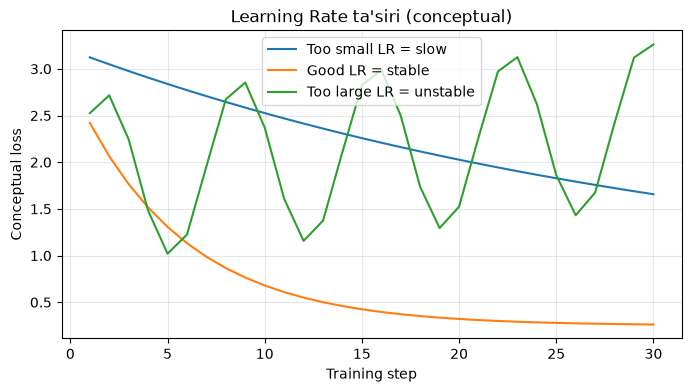

In [11]:
print("Current optimizer learning rate:", optimizer.param_groups[0]["lr"])

demo_lrs = [0.0001, 0.001, 0.1]
demo_optimizers = [
    optim.Adam(model.parameters(), lr=lr)
    for lr in demo_lrs
]

for lr, demo_optimizer in zip(demo_lrs, demo_optimizers):
    print(f"Demo Adam optimizer with lr={lr}:",
          demo_optimizer.param_groups[0]["lr"])

# Konseptual graph: bu real training emas, faqat tushuncha uchun.
steps = np.arange(1, 31)
too_small_lr = 2.6 * np.exp(-0.03 * steps) + 0.6
good_lr = 2.6 * np.exp(-0.18 * steps) + 0.25
too_large_lr = 1.8 + 0.9 * np.sin(steps * 0.9) + 0.02 * steps

plt.figure(figsize=(8, 4))
plt.plot(steps, too_small_lr, label="Too small LR = slow")
plt.plot(steps, good_lr, label="Good LR = stable")
plt.plot(steps, too_large_lr, label="Too large LR = unstable")
plt.xlabel("Training step")
plt.ylabel("Conceptual loss")
plt.title("Learning Rate ta'siri (conceptual)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
        


## Qisqa xulosa
Learning rate optimizer qadamining kattaligidir. U juda kichik bo'lsa training sekinlashadi, juda katta bo'lsa training beqaror bo'lishi mumkin.
        


---

# 11. Full Training Loop

## Tushuncha
Training loop modelni haqiqiy o'rgatadigan asosiy jarayondir.

Training loop qadamlari:

1. Batch olish
2. Forward pass
3. Loss hisoblash
4. Gradientlarni tozalash
5. Backpropagation
6. Optimizer step
7. Lossni saqlash
8. Keyingi batchga o'tish

## Real-life analogy
Bu talabaning ko'p mashq yechishiga o'xshaydi:

- Savolni ko'radi.
- Javob beradi.
- Xatosini ko'radi.
- To'g'rilaydi.
- Keyingi savolga o'tadi.

## Kod
Modelni 20 epoch train qilamiz.
        


In [12]:
num_epochs = 20

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 1) Eski gradientlarni tozalash
        optimizer.zero_grad()

        # 2) Forward pass
        outputs = model(images)

        # 3) Loss hisoblash
        loss = criterion(outputs, labels)

        # 4) Backpropagation
        loss.backward()

        # 5) Weightlarni yangilash
        optimizer.step()

        # 6) Statistikalarni yig'ish
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch + 1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")
        


Epoch [1/20] - Loss: 2.1704 - Accuracy: 18.65%
Epoch [2/20] - Loss: 1.8739 - Accuracy: 33.45%
Epoch [3/20] - Loss: 1.6543 - Accuracy: 41.20%
Epoch [4/20] - Loss: 1.5059 - Accuracy: 46.45%
Epoch [5/20] - Loss: 1.3845 - Accuracy: 50.80%
Epoch [6/20] - Loss: 1.3007 - Accuracy: 54.05%
Epoch [7/20] - Loss: 1.2240 - Accuracy: 56.50%
Epoch [8/20] - Loss: 1.1687 - Accuracy: 58.85%
Epoch [9/20] - Loss: 1.0915 - Accuracy: 61.15%
Epoch [10/20] - Loss: 1.0345 - Accuracy: 63.65%
Epoch [11/20] - Loss: 0.9617 - Accuracy: 66.35%
Epoch [12/20] - Loss: 0.9051 - Accuracy: 69.10%
Epoch [13/20] - Loss: 0.8426 - Accuracy: 71.35%
Epoch [14/20] - Loss: 0.7762 - Accuracy: 73.75%
Epoch [15/20] - Loss: 0.7012 - Accuracy: 76.65%
Epoch [16/20] - Loss: 0.6410 - Accuracy: 78.65%
Epoch [17/20] - Loss: 0.5848 - Accuracy: 81.65%
Epoch [18/20] - Loss: 0.5497 - Accuracy: 82.25%
Epoch [19/20] - Loss: 0.4745 - Accuracy: 85.25%
Epoch [20/20] - Loss: 0.4464 - Accuracy: 86.10%


## Qisqa xulosa
Training loop har bir batchda forward pass, loss, backward va optimizer stepni bajaradi. 3 epoch davomida model weightlari bir necha marta yangilanadi.
        


---

# 12. Validation nima?

## Tushuncha
**Validation** yoki test evaluation model trainingdan tashqari datada qanday ishlayotganini tekshiradi.

Validationda:

- weight yangilanmaydi.
- `model.eval()` ishlatiladi.
- `torch.no_grad()` ishlatiladi.

Bu trainingdan yengilroq va tezroq, chunki gradient hisoblanmaydi.

## Real-life analogy
Talaba mashq darsida o'rgandi. Keyin kichik test bilan tekshiramiz. Testda teacher yordam bermaydi, faqat natija ko'riladi.

## Kod
Evaluation function yozamiz va test datada loss hamda accuracy hisoblaymiz.
        


In [13]:
def evaluate(model, data_loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(data_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


test_loss, test_accuracy = evaluate(model, test_loader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
        


Test Loss: 1.9306
Test Accuracy: 43.60%


## Qisqa xulosa
Validation model trainingda ko'rmagan yoki trainingdan alohida datada qanday ishlashini tekshiradi. `model.eval()` evaluation modega o'tkazadi, `torch.no_grad()` gradient hisoblashni o'chiradi.
        


---

# 13. Training Graphs

## Tushuncha
Graphlar model training davomida qanday o'rganayotganini ko'rsatadi.

- Loss pastga tushsa, bu odatda yaxshi belgi.
- Accuracy yuqoriga chiqsa, bu ham yaxshi belgi.

Lekin graphlarni doim validation natijalari bilan birga ko'rish kerak.

## Real-life analogy
Bu sportchining progress chartiga o'xshaydi. Har kuni natija yozib borilsa, rivojlanish ko'rinadi.

## Kod
Training loss va training accuracy curve chizamiz.
        


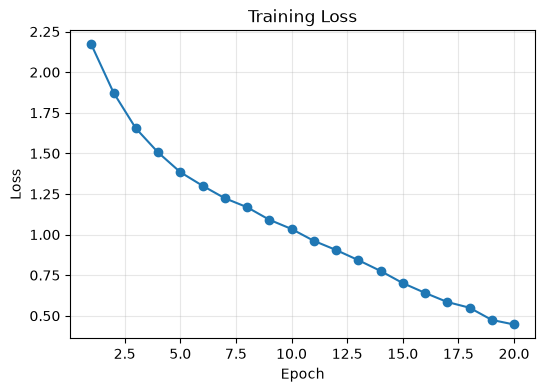

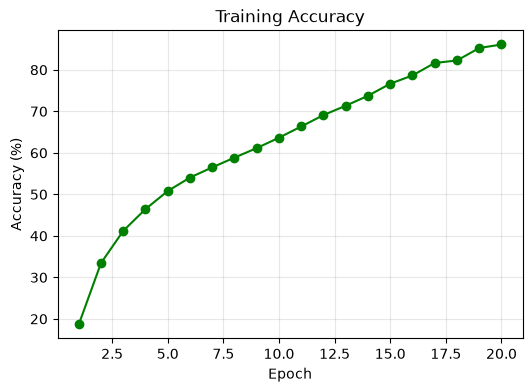

In [14]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accuracies, marker="o", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")
plt.grid(True, alpha=0.3)
plt.show()
        


## Qisqa xulosa
Loss curve model xatosi qanday o'zgarayotganini, accuracy curve esa to'g'ri predictionlar foizi qanday o'zgarayotganini ko'rsatadi.
        


---

# 14. Prediction Example

## Tushuncha
Endi modelni test datasetdan olingan bir nechta rasmda sinab ko'ramiz.

Bu **inference**ga o'xshaydi: model input oladi va prediction chiqaradi. Lekin bu hali deployment emas, faqat notebook ichida tekshirish.

## Real-life analogy
Talaba darsdan keyin yangi savollarni mustaqil yechib ko'radi. Biz uning javobini to'g'ri javob bilan solishtiramiz.

## Kod
Bir nechta test rasm uchun predicted label, true label va confidence score ko'rsatamiz.
        


First 8 predictions:
1. True: cat        | Predicted: dog        | Confidence: 55.20%
2. True: ship       | Predicted: ship       | Confidence: 71.87%
3. True: ship       | Predicted: airplane   | Confidence: 84.65%
4. True: airplane   | Predicted: ship       | Confidence: 56.97%
5. True: frog       | Predicted: frog       | Confidence: 39.73%
6. True: frog       | Predicted: cat        | Confidence: 63.49%
7. True: automobile | Predicted: dog        | Confidence: 80.18%
8. True: frog       | Predicted: frog       | Confidence: 47.68%


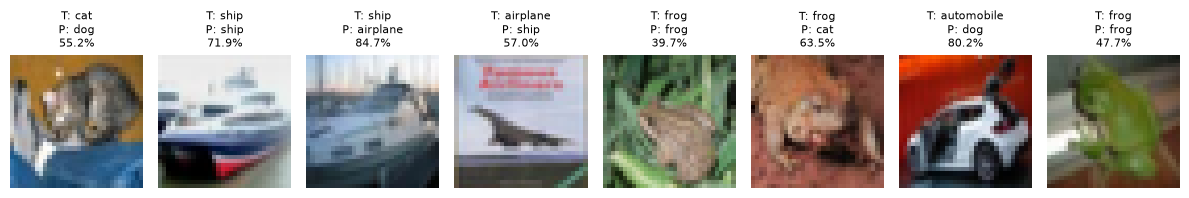

In [15]:
model.eval()

test_images, test_labels = next(iter(test_loader))
test_images_device = test_images.to(device)

with torch.no_grad():
    test_outputs = model(test_images_device)
    test_probs = torch.softmax(test_outputs, dim=1)
    confidences, predictions = torch.max(test_probs, dim=1)

print("First 8 predictions:")
for i in range(8):
    true_name = classes[int(test_labels[i])]
    pred_name = classes[int(predictions[i])]
    conf = float(confidences[i]) * 100
    print(f"{i + 1}. True: {true_name:10s} | Predicted: {pred_name:10s} | Confidence: {conf:.2f}%")

show_image_grid(
    test_images,
    labels=test_labels,
    predictions=predictions.cpu(),
    confidences=confidences.cpu(),
    max_images=8
)
        


## Qisqa xulosa
Prediction example modelning amalda qanday javob berishini ko'rsatadi. Confidence score softmax probabilitydan olinadi.
        


---

# 15. Save Model

## Tushuncha
Trainingdan keyin modelni saqlash kerak. Aks holda notebook yopilganda model weightlari yo'qoladi.

PyTorchda odatda `state_dict` saqlanadi. `state_dict` modelning o'rgangan weightlarini o'z ichiga oladi.

## Real-life analogy
Bu darsdan keyingi daftarni saqlab qo'yishga o'xshaydi. Keyingi darsda shu joydan davom etish mumkin.

## Kod
`Lesson4/models` papkasini yaratamiz, model weightlarini `.pth` faylga saqlaymiz va class nomlarini ham saqlaymiz.
        


In [16]:
models_dir = LESSON_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "simple_cnn_cifar10.pth"
class_json_path = models_dir / "class_names.json"
class_txt_path = models_dir / "classes.txt"

# Model weightlarini saqlash
torch.save(model.state_dict(), model_path)

# Class nomlarini JSON formatda saqlash
with open(class_json_path, "w", encoding="utf-8") as f:
    json.dump(classes, f, ensure_ascii=False, indent=2)

# Class nomlarini oddiy txt formatda saqlash
with open(class_txt_path, "w", encoding="utf-8") as f:
    for class_name in classes:
        f.write(class_name + "\n")

print("Model saved to:", model_path)
print("Class names saved to:", class_json_path)
print("Class txt saved to:", class_txt_path)
print("Relative model path: Lesson4/models/simple_cnn_cifar10.pth")
        


Model saved to: C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 1\4 dars\Lesson4\models\simple_cnn_cifar10.pth
Class names saved to: C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 1\4 dars\Lesson4\models\class_names.json
Class txt saved to: C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 1\4 dars\Lesson4\models\classes.txt
Relative model path: Lesson4/models/simple_cnn_cifar10.pth


## Qisqa xulosa
Modelni saqlash deployment va keyingi inference uchun muhim. `state_dict` model architecture emas, balki o'rgangan weightlarni saqlaydi.
        


---

# 16. Load Model Again

## Tushuncha
Saqlangan modelni qayta yuklab ishlatish mumkin. Bu deployment bosqichi uchun juda muhim.

Yuklashda:

1. Avval model architecture qayta yaratiladi.
2. Keyin saqlangan `state_dict` load qilinadi.
3. Model `eval()` modega o'tkaziladi.

## Real-life analogy
Saqlangan daftarni keyingi darsda ochib, o'qishni davom ettirishga o'xshaydi.

## Kod
Yangi model object yaratamiz, saqlangan weightlarni yuklaymiz va bitta rasmda prediction qilamiz.
        


True label: cat
Predicted label: dog
Confidence: 55.20%


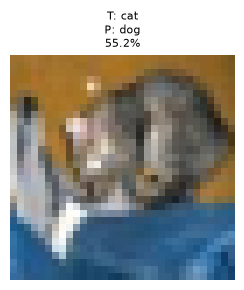

In [17]:
loaded_model = SimpleCNN(num_classes=len(classes)).to(device)

# map_location=device modelni hozirgi devicega moslab yuklaydi.
loaded_state_dict = torch.load(model_path, map_location=device)
loaded_model.load_state_dict(loaded_state_dict)
loaded_model.eval()

single_image, single_label = test_dataset[0]
single_input = single_image.unsqueeze(0).to(device)

with torch.no_grad():
    single_output = loaded_model(single_input)
    single_prob = torch.softmax(single_output, dim=1)
    single_confidence, single_prediction = torch.max(single_prob, dim=1)

print("True label:", classes[int(single_label)])
print("Predicted label:", classes[int(single_prediction.item())])
print("Confidence:", f"{single_confidence.item() * 100:.2f}%")

show_image_grid(
    single_image.unsqueeze(0),
    labels=torch.tensor([single_label]),
    predictions=single_prediction.cpu(),
    confidences=single_confidence.cpu(),
    max_images=1
)
        


## Qisqa xulosa
Modelni qayta yuklash uchun bir xil architecture kerak. Keyin `load_state_dict()` orqali o'rgangan weightlar qayta tiklanadi.
        


---

# 17. Lesson 4 Final Summary

## Tushuncha
Bu darsda model training jarayonining asosiy qismlarini ko'rdik.

| Concept | What it means | Why important |
|---|---|---|
| Forward Pass | Input modeldan o'tib prediction chiqaradi | Modelning hozirgi javobini olish uchun kerak |
| Loss | Prediction xatosini raqam bilan o'lchaydi | Model qanchalik adashayotganini bilamiz |
| Backpropagation | Loss asosida gradientlarni hisoblaydi | Weightlar qaysi tomonga o'zgarishini ko'rsatadi |
| Optimizer | Gradientlar yordamida weightlarni yangilaydi | Model lossni kamaytirib o'rganadi |
| Learning Rate | Optimizer qadamining kattaligi | Training tezligi va barqarorligiga ta'sir qiladi |
| Batch | Datasetning kichik qismi | Katta datasetni qulay o'rgatish uchun kerak |
| Epoch | Butun training datasetni bir marta ko'rish | Modelga takroriy o'rganish imkonini beradi |
| Validation | Trainingdan tashqari datada tekshirish | Model umumiy ishlashini baholaydi |

## Real-life analogy
Training jarayoni talabaning mashq qilishiga o'xshaydi: savol ko'radi, javob beradi, xatosini biladi, tuzatadi va yana mashq qiladi.

## Final flow
Input -> Forward Pass -> Prediction -> Loss -> Backpropagation -> Optimizer Step -> Repeat -> Better Model

## Kod
Darsning yakuniy flowini yana bir marta chiqaramiz.
        


In [19]:
final_flow = "Input -> Forward Pass -> Prediction -> Loss -> Backpropagation -> Optimizer Step -> Repeat -> Better Model"
print(final_flow)

print("\nLesson 4 tugadi. Endi model training jarayonining asosiy bosqichlarini bilamiz.")
        


Input -> Forward Pass -> Prediction -> Loss -> Backpropagation -> Optimizer Step -> Repeat -> Better Model

Lesson 4 tugadi. Endi model training jarayonining asosiy bosqichlarini bilamiz.


## Qisqa xulosa
Model trainingi bir martalik amal emas. U batchlar va epochlar orqali takrorlanadigan jarayon: prediction, loss, gradient, optimizer update va yana takrorlash.
        
